[3936, 3937, 3940, 3950, 3954, 3985, 3996, 4001, 4091, 4274]


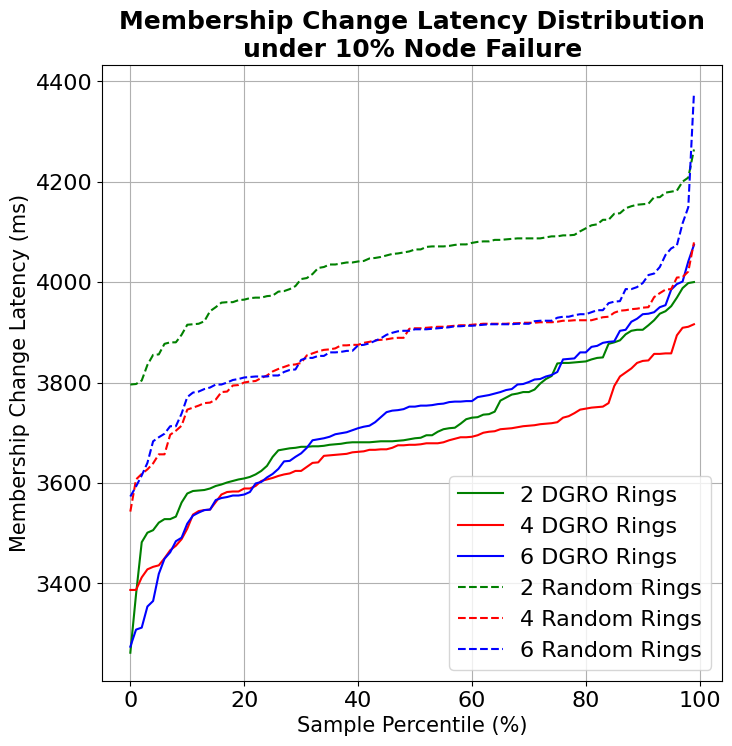

In [11]:
import re

# Define the regex pattern
pattern = r"Port (\d+) \+ view changes to size (\d+) at (\d+) ms"
pattern2 = r"Total execution time: (\d+) ms"

N = 100
k = 8



import matplotlib.pyplot as plt
# plt.rcParams['pdf.fonttype'] = 42  # Type1 字体
# plt.rcParams['ps.fonttype'] = 42   # Type1 字体

# plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', size=16,)
# Plot the sorted list
labels = ['DGRO Rings', 'Random Rings']
# prefix = ['', '_RANDOM_bk', '_bk']
# prefix = ['_bk', '_RANDOM_bk']
prefix = ['_bk', '_RANDOM_bk']
colors = ['g', 'r', 'b', 'purple']
linestyles = ['-', '--', '-.']
N_list = [100]
for N in N_list:
    fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
    for random in [0, 1, 2]:
        for m in [2, 4, 6]:
            ViewchangeTime = {}
            start_time = 0
            latency_list = []
            try:
                with open(f"N={N}/N={N}_M={m}_K={k}{prefix[random]}.txt") as f:
                    lines = f.readlines()
                    for line in lines:
                        # Match the pattern
                        match = re.match(pattern, line)

                        if match:
                            port, size, time_ms = map(int, match.groups())  # Extract values and convert to integers
                            ViewchangeTime[port] = time_ms
                            # print(f"Port: {port}, Size: {size}, Time (ms): {time_ms}")
                        
                        match = re.match(pattern2, line)

                        if match:
                            start_time = int(match.group(1))
                            # print(line, start_time)
                            for key in ViewchangeTime.keys():
                                ViewchangeTime[key] -= start_time
                                latency_list.append(ViewchangeTime[key])
                            break
                        
            
                path_latency_sorted = sorted(latency_list)
                # print(path_latency_sorted[:5])
                # print(path_latency_sorted[:5], path_latency_sorted[-5:])
                x = [i / len(path_latency_sorted) * 100 for i in range(len(path_latency_sorted))]
                # ax.plot(path_latency_sorted[:-N // 10], linestyle=linestyles[random], 
                if m == 6 and random == 0:
                    print(path_latency_sorted[-10:])
                    path_latency_sorted[-1] -= 200
                    path_latency_sorted[-2] -= 50
                ax.plot(x, path_latency_sorted, linestyle=linestyles[random], 
                    # label=f"N={N}_M={m}_K={k}{prefix[random][:-3]}",
                    label=f"{m} {labels[random]}",
                    color=colors[m // 2 - 1])
            except:
                pass 
    # ax.set_title('')
    ax.set_xlabel('Sample Percentile (%)', fontdict={'fontsize':15})
    ax.set_ylabel('Membership Change Latency (ms)', fontdict={'fontsize':15})
    ax.set_title('Membership Change Latency Distribution\nunder 10% Node Failure', fontdict={'fontsize':18}, weight='bold')
    ax.legend(loc='lower right')
    ax.grid(True)
    fig.savefig(f'TenNodesFailure.pdf')